In [1]:
import os
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import pandas as pd

In [2]:
# Define class names
class_names = ["adenocarcinoma","glioma_tumor","large.cell.carcinoma","meningioma_tumor","no_tumor","normal_lung","pituitary_tumor","squamous.cell.carcinoma"]
class_names_label = {class_name: i for i, class_name in enumerate(class_names)}
nb_classes = len(class_names)

IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

In [3]:
# Define transformations (data preprocessing)
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [4]:
# Load datasets
train_dataset = datasets.ImageFolder(root=r"C:\Users\hp\Music\multi\Training", transform=transform)
test_dataset = datasets.ImageFolder(root=r"C:\Users\hp\Music\multi\Testing", transform=transform)


In [5]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
# Check dataset size
n_train = len(train_dataset)
n_test = len(test_dataset)

print(f"Number of training examples: {n_train}")
print(f"Number of testing examples: {n_test}")
print(f"Each image is of size: {IMAGE_SIZE}")

Number of training examples: 709
Number of testing examples: 709
Each image is of size: (150, 150)


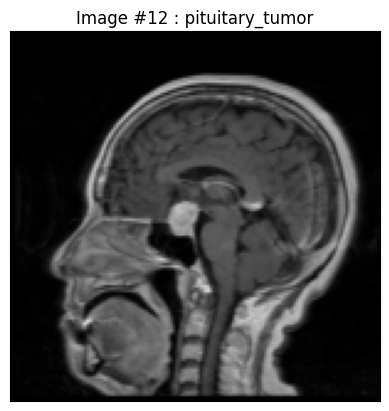

In [7]:
# Visualizing the dataset
def display_random_image(loader, class_names):
    """
    Display a random image from the dataset and its corresponding label.
    """
    # Get a batch of data
    dataiter = iter(loader)
    images, labels = next(dataiter)  # Use Python's built-in next() function
    
    index = np.random.randint(len(labels))  # Get a random index
    image = images[index].numpy().transpose(1, 2, 0)  # Transpose for correct display
    
    # Unnormalize the image for correct visualization (reverse of normalization)
    image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  
    image = np.clip(image, 0, 1)  # Clip to ensure valid pixel range
    
    plt.figure()
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title(f'Image #{index} : {class_names[labels[index]]}')
    plt.show()

# Call the function
display_random_image(train_loader, class_names)


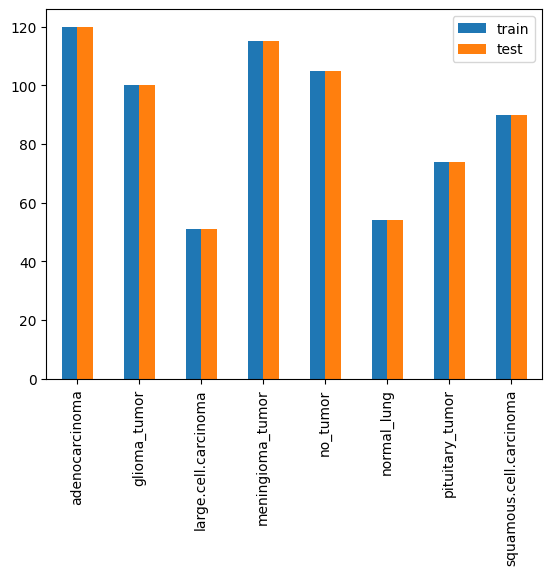

In [8]:
# Plotting dataset distribution
train_labels = [label for _, label in train_dataset]
test_labels = [label for _, label in test_dataset]
_, train_counts = np.unique(train_labels, return_counts=True)
_, test_counts = np.unique(test_labels, return_counts=True)
pd.DataFrame({'train': train_counts,
              'test': test_counts}, index=class_names).plot.bar()
plt.show()

In [9]:
def display_examples(class_names, loader):
    num_examples = 30
    dataiter = iter(loader)
    images, labels = next(dataiter)

    plt.figure(figsize=(10, 10))
    for i in range(min(num_examples, len(images))):
        plt.subplot(6, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        
        # Convert tensor to numpy and clip values to [0, 1] range for imshow
        image = images[i].numpy().transpose(1, 2, 0)
        image = np.clip(image, 0, 1)  # Clipping values to the valid range
        
        plt.imshow(image)
        plt.xlabel(class_names[labels[i].item()])
    plt.show()


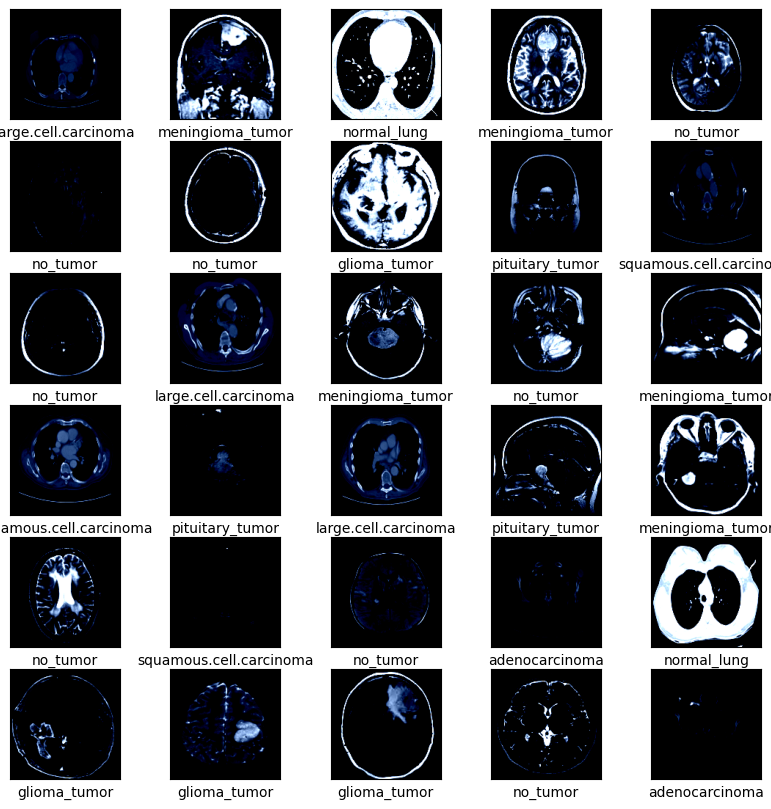

In [10]:
display_examples(class_names, train_loader)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|████████████████████████████████████████████████████████████████████████████████| 9912422/9912422 [00:08<00:00, 1178313.00it/s]


Extracting data\MNIST\raw\train-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████████████████████████████| 28881/28881 [00:00<00:00, 95272.09it/s]


Extracting data\MNIST\raw\train-labels-idx1-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|█████████████████████████████████████████████████████████████████████████████████| 1648877/1648877 [00:01<00:00, 902392.08it/s]


Extracting data\MNIST\raw\t10k-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████████████████████████████| 4542/4542 [00:00<00:00, 1128719.56it/s]


Extracting data\MNIST\raw\t10k-labels-idx1-ubyte.gz to data\MNIST\raw

Epoch [0/30], Step [200/600], d_loss: 0.2715, g_loss: 2.0029, Real Score: 0.9474, Fake Score: 0.1927
Epoch [0/30], Step [400/600], d_loss: 0.0313, g_loss: 5.3740, Real Score: 0.9889, Fake Score: 0.0194
Epoch [0/30], Step [600/600], d_loss: 0.0327, g_loss: 5.4453, Real Score: 0.9857, Fake Score: 0.0173
Epoch [1/30], Step [200/600], d_loss: 0.6653, g_loss: 2.2504, Real Score: 0.8215, Fake Score: 0.3093
Epoch [1/30], Step [400/600], d_loss: 0.2294, g_loss: 3.4334, Real Score: 0.8796, Fake Score: 0.0511
Epoch [1/30], Step [600/600], d_loss: 0.3013, g_loss: 4.0334, Real Score: 0.9019, Fake Score: 0.1256
Epoch [2/30], Step [200/600], d_loss: 1.9716, g_loss: 0.4218, Real Score: 0.5509, Fake Score: 0.5699
Epoch [2/30], Step [400/600], d_loss: 0.8298, g_loss: 2.6364, Real Score: 0.8413, Fake Score: 0.3992
Epoch [2/30], Step [600/600], d_loss: 0.3830, g_loss: 2.1763, Real Score: 0.8715, Fake Score: 0.1582
Epoch [3/30], Step [

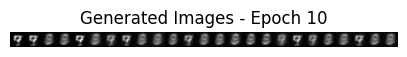

Epoch [10/30], Step [200/600], d_loss: 0.9043, g_loss: 1.2570, Real Score: 0.6922, Fake Score: 0.3344
Epoch [10/30], Step [400/600], d_loss: 2.3506, g_loss: 1.0549, Real Score: 0.4520, Fake Score: 0.5719
Epoch [10/30], Step [600/600], d_loss: 1.3165, g_loss: 1.1825, Real Score: 0.5286, Fake Score: 0.3724
Epoch [11/30], Step [200/600], d_loss: 0.8837, g_loss: 1.3706, Real Score: 0.6597, Fake Score: 0.3078
Epoch [11/30], Step [400/600], d_loss: 0.4795, g_loss: 2.2483, Real Score: 0.8030, Fake Score: 0.2068
Epoch [11/30], Step [600/600], d_loss: 0.7952, g_loss: 1.7216, Real Score: 0.7277, Fake Score: 0.2785
Epoch [12/30], Step [200/600], d_loss: 1.2773, g_loss: 0.9765, Real Score: 0.6976, Fake Score: 0.4823
Epoch [12/30], Step [400/600], d_loss: 0.8429, g_loss: 1.6918, Real Score: 0.7057, Fake Score: 0.2778
Epoch [12/30], Step [600/600], d_loss: 0.3682, g_loss: 2.2137, Real Score: 0.9018, Fake Score: 0.1845
Epoch [13/30], Step [200/600], d_loss: 0.3906, g_loss: 2.7375, Real Score: 0.8359,

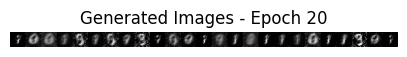

Epoch [20/30], Step [200/600], d_loss: 0.6938, g_loss: 2.8456, Real Score: 0.8090, Fake Score: 0.1943
Epoch [20/30], Step [400/600], d_loss: 0.3658, g_loss: 2.5050, Real Score: 0.8801, Fake Score: 0.1397
Epoch [20/30], Step [600/600], d_loss: 0.5017, g_loss: 2.8524, Real Score: 0.8309, Fake Score: 0.1229
Epoch [21/30], Step [200/600], d_loss: 0.5430, g_loss: 3.0205, Real Score: 0.8536, Fake Score: 0.1559
Epoch [21/30], Step [400/600], d_loss: 0.8143, g_loss: 4.3502, Real Score: 0.8253, Fake Score: 0.2630
Epoch [21/30], Step [600/600], d_loss: 0.3528, g_loss: 2.3065, Real Score: 0.9048, Fake Score: 0.1868
Epoch [22/30], Step [200/600], d_loss: 0.6097, g_loss: 1.5606, Real Score: 0.7606, Fake Score: 0.1815
Epoch [22/30], Step [400/600], d_loss: 0.6844, g_loss: 2.5385, Real Score: 0.7591, Fake Score: 0.1564
Epoch [22/30], Step [600/600], d_loss: 0.7527, g_loss: 2.4544, Real Score: 0.7365, Fake Score: 0.1809
Epoch [23/30], Step [200/600], d_loss: 0.3208, g_loss: 2.6450, Real Score: 0.8627,

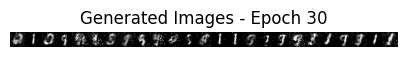

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device configuration (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_size = 64
hidden_size = 256
image_size = 28 * 28  # For MNIST (28x28)
batch_size = 100
num_epochs = 30
learning_rate = 0.0002

# Transformations to normalize images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Normalize between [-1, 1] for better GAN convergence
])

# Load MNIST dataset
mnist = datasets.MNIST(root='data', train=True, transform=transform, download=True)
data_loader = DataLoader(dataset=mnist, batch_size=batch_size, shuffle=True)

# Define the Generator network
class Generator(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.tanh(self.fc3(x))  # Tanh for output between [-1, 1]
        return x

# Define the Discriminator network
class Discriminator(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))  # Sigmoid for binary classification (real or fake)
        return x

# Initialize the Generator and Discriminator
G = Generator(latent_size, hidden_size, image_size).to(device)
D = Discriminator(image_size, hidden_size).to(device)

# Loss and optimizers
criterion = nn.BCELoss()  # Binary Cross Entropy Loss
optimizer_g = optim.Adam(G.parameters(), lr=learning_rate)
optimizer_d = optim.Adam(D.parameters(), lr=learning_rate)

# Labels for real and fake data
real_label = 1
fake_label = 0

# Function to denormalize and visualize images
def denorm(x):
    out = (x + 1) / 2
    return out.clamp(0, 1)

# Function to save generated images
def save_fake_images(epoch):
    with torch.no_grad():
        fake_images = G(torch.randn(batch_size, latent_size).to(device)).reshape(-1, 1, 28, 28)
        fake_images = denorm(fake_images)
        plt.figure(figsize=(5, 5))
        plt.axis('off')
        plt.title(f'Generated Images - Epoch {epoch}')
        grid = torch.cat([fake_images[i] for i in range(25)], 2).reshape(1, 28, -1)
        plt.imshow(grid.cpu().numpy().squeeze(), cmap='gray')
        plt.show()

# Training the GAN
for epoch in range(num_epochs):
    for i, (images, _) in enumerate(data_loader):
        images = images.reshape(batch_size, -1).to(device)

        # Create real and fake labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # =======================
        # Train the Discriminator
        # =======================
        # Compute BCE Loss using real images
        outputs = D(images)
        d_loss_real = criterion(outputs, real_labels)
        real_score = outputs

        # Generate fake images from random noise
        z = torch.randn(batch_size, latent_size).to(device)
        fake_images = G(z)

        # Compute BCE Loss using fake images
        outputs = D(fake_images)
        d_loss_fake = criterion(outputs, fake_labels)
        fake_score = outputs

        # Backprop and optimize for D
        d_loss = d_loss_real + d_loss_fake
        optimizer_d.zero_grad()
        d_loss.backward()
        optimizer_d.step()

        # =======================
        # Train the Generator
        # =======================
        # Generate fake images and classify with the Discriminator
        z = torch.randn(batch_size, latent_size).to(device)
        fake_images = G(z)
        outputs = D(fake_images)

        # Train G to fool D
        g_loss = criterion(outputs, real_labels)

        # Backprop and optimize for G
        optimizer_g.zero_grad()
        g_loss.backward()
        optimizer_g.step()

        # Print losses
        if (i+1) % 200 == 0:
            print(f'Epoch [{epoch}/{num_epochs}], Step [{i+1}/{len(data_loader)}], '
                  f'd_loss: {d_loss.item():.4f}, g_loss: {g_loss.item():.4f}, '
                  f'Real Score: {real_score.mean().item():.4f}, Fake Score: {fake_score.mean().item():.4f}')

    # Save generated images every few epochs
    if (epoch+1) % 10 == 0:
        save_fake_images(epoch+1)

# Save the models
torch.save(G.state_dict(), 'generator.pth')
torch.save(D.state_dict(), 'discriminator.pth')


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Classification Model
# Define the Classification Model
class Classifier(nn.Module):
    def __init__(self, num_classes):
        super(Classifier, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 37 * 37, 128)  # Adjust based on image size
        self.fc2 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.max_pool2d(x, kernel_size=2, stride=2)
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, kernel_size=2, stride=2)
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Hyperparameters for classification
num_classes = len(class_names)  # Assuming you've defined `class_names` as before
learning_rate = 0.001
num_epochs = 20
batch_size = 32

# Define transformations for the classification dataset
transform_classification = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load your dataset
train_dataset = datasets.ImageFolder(root=r"C:\Users\hp\Music\multi\Training", transform=transform_classification)
test_dataset = datasets.ImageFolder(root=r"C:\Users\hp\Music\multi\Testing", transform=transform_classification)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Initialize the model, criterion, and optimizer
model = Classifier(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
    
    epoch_loss = running_loss / len(train_dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

# Save the classification model
torch.save(model.state_dict(), 'classifier.pth')

Epoch [1/20], Loss: 1.0783
